In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader, random_split, Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import wandb
wandb.init(project="flower-simulation-tutorial", name=f"custom-strategy-ground-truth_net2")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rafast to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [3]:
# Configuración
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001

# Definición del modelo

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.dropout1 = nn.Dropout(0.7)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.6)
        self.fc3 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout1(F.relu(self.fc1(x)))
        x = self.dropout2(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x
# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.conv1 = nn.Conv2d(3, 16, 3, 1)
#         self.conv2 = nn.Conv2d(16, 32, 3, 1)
#         self.fc1 = nn.Linear(32*6*6, 128)
#         self.fc2 = nn.Linear(128, 10)  # Asegúrate que coincida con el nº de clases

#     def forward(self, x):
#         x = nn.functional.relu(self.conv1(x))
#         x = nn.functional.max_pool2d(x, 2)
#         x = nn.functional.relu(self.conv2(x))
#         x = nn.functional.max_pool2d(x, 2)
#         x = x.view(x.size(0), -1)
#         x = nn.functional.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x


# Transformaciones

In [ ]:
from torchvision import transforms
pytorch_transforms = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Carga del dataset desde HuggingFace

In [6]:
dataset = load_dataset("RaFast/RepoMED")

Resolving data files:   0%|          | 0/389 [00:00<?, ?it/s]

# Dataset personalizado para PyTorch

In [7]:
class RepoMEDImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __getitem__(self, idx):
        image = self.data[idx]["image"]
        # If the image is a numpy array, convert to PIL
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert("RGB")
        label = self.data[idx]["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.data)


# Convertimos a la clase Dataset para aplicar transformaciones de PyTorch

In [8]:
full_dataset = RepoMEDImageDataset(dataset["train"], transform=pytorch_transforms)

# Split 80/20 usando random_split

In [9]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inicialización

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Entrenamiento

In [12]:
train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)  # suma loss por batch
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_losses.append(running_loss/total)
    train_accs.append(correct/total)
    
    # Evaluación
    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_losses.append(test_loss/total)
    test_accs.append(correct/total)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Acc: {train_accs[-1]:.2f}, Test Acc: {test_accs[-1]:.2f}")
    # Log to W&B
    wandb.log({
        'train_loss': running_loss/total,
        'test_loss': test_loss/total,
        'train_acc': train_accs[-1],
        'test_acc': test_accs[-1]
    })



Epoch [1/30], Train Acc: 0.38, Test Acc: 0.41
Epoch [2/30], Train Acc: 0.48, Test Acc: 0.45
Epoch [3/30], Train Acc: 0.53, Test Acc: 0.69
Epoch [4/30], Train Acc: 0.63, Test Acc: 0.67
Epoch [5/30], Train Acc: 0.66, Test Acc: 0.69
Epoch [6/30], Train Acc: 0.68, Test Acc: 0.78
Epoch [7/30], Train Acc: 0.70, Test Acc: 0.79
Epoch [8/30], Train Acc: 0.71, Test Acc: 0.78
Epoch [9/30], Train Acc: 0.69, Test Acc: 0.74
Epoch [10/30], Train Acc: 0.68, Test Acc: 0.74
Epoch [11/30], Train Acc: 0.71, Test Acc: 0.78
Epoch [12/30], Train Acc: 0.72, Test Acc: 0.81
Epoch [13/30], Train Acc: 0.73, Test Acc: 0.86
Epoch [14/30], Train Acc: 0.75, Test Acc: 0.83
Epoch [15/30], Train Acc: 0.72, Test Acc: 0.78
Epoch [16/30], Train Acc: 0.73, Test Acc: 0.78
Epoch [17/30], Train Acc: 0.71, Test Acc: 0.81
Epoch [18/30], Train Acc: 0.73, Test Acc: 0.79
Epoch [19/30], Train Acc: 0.73, Test Acc: 0.82
Epoch [20/30], Train Acc: 0.77, Test Acc: 0.83
Epoch [21/30], Train Acc: 0.77, Test Acc: 0.85
Epoch [22/30], Train A

# Ploteo de accuracy y loss

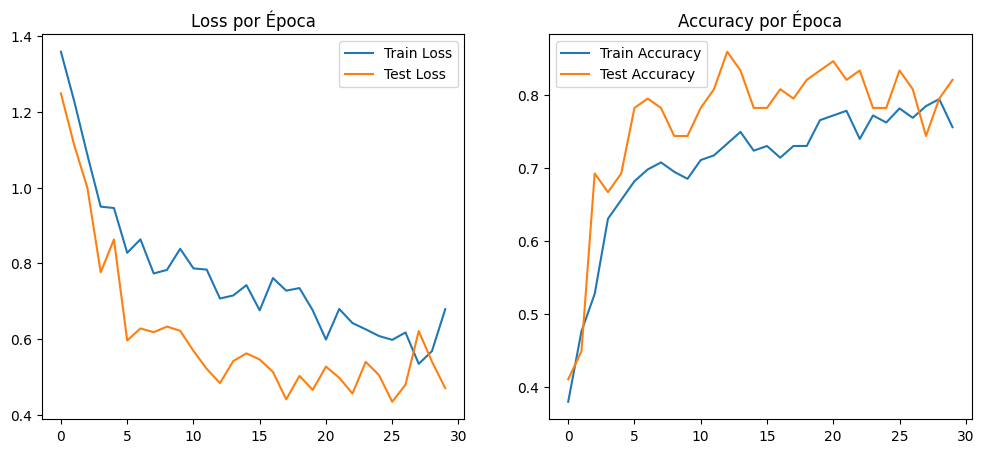

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Loss por Época')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.legend()
plt.title('Accuracy por Época')

plt.show()